In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from pydantic import BaseModel, Field
from dotenv import load_dotenv
import operator

/home/sahil/Desktop/LANGGRAPH/myenv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
load_dotenv()
model = ChatOpenAI(model="gpt-4o-mini")

In [3]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Detailed feedback on the essay, including strengths and areas for improvement.")
    score: float = Field(description="A score between 0 and 10 evaluating the overall quality of the essay.", ge=0, le=10)

structured_model = model.with_structured_output(EvaluationSchema)

In [4]:
essay = (
    "The convergence of neuroscience and artificial intelligence (AI) represents one of the most transformative "
    "intellectual partnerships of the 21st century. Neuroscience seeks to unravel the mechanisms of the human brain "
    "while AI attempts to replicate aspects of intelligence in machines. What began as a relationship of inspiration "
    "has matured into a dynamic bidirectional exchange.\n\n"
    "Early artificial neural networks were loosely inspired by neurons, but modern AI has drawn from far more precise "
    "neuroscientific findings. The work of Hubel and Wiesel on the visual cortex directly influenced convolutional "
    "neural networks (CNNs). Attention mechanisms in modern AI echo cognitive processes studied in neuroscience.\n\n"
    "Reinforcement learning is strongly influenced by the brain's reward systems, particularly dopamine signaling. "
    "Brain-computer interfaces (BCIs) use AI to translate neural activity into actionable outputs, restoring movement "
    "in paralyzed individuals and enabling text generation from neural signals.\n\n"
    "Despite these advances, AI still requires vast datasets, lacks true general intelligence, and raises serious "
    "ethical concerns around neural data privacy, consent, and cognitive liberty."
)

## State Definition

In [5]:
class EssayState(TypedDict):
    essay: str
    language_feedback: str
    depth_of_analysis_feedback: str
    clarity_of_thought_feedback: str          # FIX: typo corrected
    overall_feedback: str
    individual_scores: Annotated[list[float], operator.add]  # operator.add merges lists from parallel branches
    avg_score: float

## Node Definitions

Each parallel node **returns a dict** (not mutated state).  
Scores are wrapped in a single-element list so `operator.add` safely merges them across parallel branches.

In [6]:
# 1. Language & Style evaluator
def evaluate_language(state: EssayState) -> dict:
    system_prompt = (
        "You are an expert writing coach. Evaluate ONLY language and style: "
        "grammar, vocabulary, sentence variety, tone, and flow. "
        "Do NOT comment on content depth or argument quality."
    )
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=state["essay"])
    ]
    response = structured_model.invoke(messages)
    return {
        "language_feedback": response.feedback,
        "individual_scores": [response.score]
    }

In [7]:
# 2. Depth of Analysis evaluator
# FIX: was mutating state directly with .append() -- wrong LangGraph pattern.
# Corrected to return a plain dict.
def evaluate_depth_of_analysis(state: EssayState) -> dict:
    system_prompt = (
        "You are an academic reviewer. Evaluate ONLY depth of analysis: "
        "quality of arguments, use of evidence, and intellectual rigor. "
        "Do NOT comment on writing style or clarity of presentation."
    )
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=state["essay"])
    ]
    response = structured_model.invoke(messages)
    return {
        "depth_of_analysis_feedback": response.feedback,
        "individual_scores": [response.score]
    }

In [8]:
# 3. Clarity of Thought evaluator
# FIX: node was referenced in graph construction but never defined.
def evaluate_clarity_of_thought(state: EssayState) -> dict:
    system_prompt = (
        "You are a communication specialist. Evaluate ONLY clarity of thought: "
        "logical structure, coherence between paragraphs, and ease of understanding. "
        "Do NOT comment on language style or analytical depth."
    )
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=state["essay"])
    ]
    response = structured_model.invoke(messages)
    return {
        "clarity_of_thought_feedback": response.feedback,
        "individual_scores": [response.score]
    }

In [9]:
# 4. Final Aggregator
# FIX: node was referenced but never defined. Now computes avg_score and overall_feedback.
def final_evaluation(state: EssayState) -> dict:
    scores = state["individual_scores"]
    avg = round(sum(scores) / len(scores), 2)

    system_prompt = (
        "You are a senior essay evaluator. You have received three specialist reviews. "
        "Write a concise overall summary (3-5 sentences) synthesising all three perspectives "
        "and give the student clear, actionable next steps."
    )
    combined = (
        f"Language & Style Review:\n{state['language_feedback']}\n\n"
        f"Depth of Analysis Review:\n{state['depth_of_analysis_feedback']}\n\n"
        f"Clarity of Thought Review:\n{state['clarity_of_thought_feedback']}"
    )
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=combined)
    ]
    overall = model.invoke(messages)
    return {
        "overall_feedback": overall.content,
        "avg_score": avg
    }

## Graph Construction

```
START
  +---> evaluate_language           ---+
  +---> evaluate_depth_of_analysis  ---+--> final_evaluation --> END
  +---> evaluate_clarity_of_thought ---+
```

In [10]:
graph = StateGraph(EssayState)

graph.add_node("evaluate_language", evaluate_language)
graph.add_node("evaluate_depth_of_analysis", evaluate_depth_of_analysis)
graph.add_node("evaluate_clarity_of_thought", evaluate_clarity_of_thought)
graph.add_node("final_evaluation", final_evaluation)

# FIX: parallel fan-out from START to all three evaluators
graph.add_edge(START, "evaluate_language")
graph.add_edge(START, "evaluate_depth_of_analysis")
graph.add_edge(START, "evaluate_clarity_of_thought")

# Fan-in: all three evaluators feed into final_evaluation
graph.add_edge("evaluate_language", "final_evaluation")
graph.add_edge("evaluate_depth_of_analysis", "final_evaluation")
graph.add_edge("evaluate_clarity_of_thought", "final_evaluation")

graph.add_edge("final_evaluation", END)

# FIX: graph was never compiled
app = graph.compile()

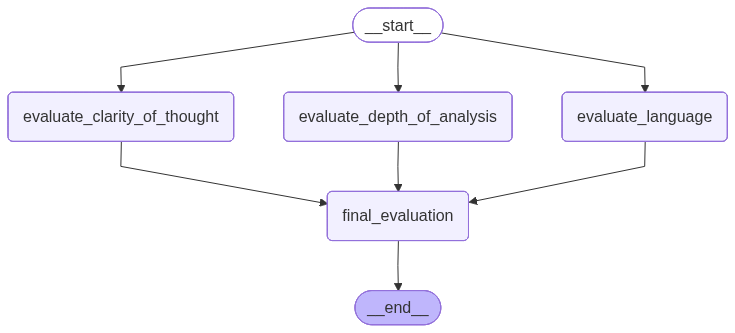

In [11]:
# Optional: visualise the graph
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

## Run the Workflow

In [12]:
initial_state: EssayState = {
    "essay": essay,
    "language_feedback": "",
    "depth_of_analysis_feedback": "",
    "clarity_of_thought_feedback": "",
    "overall_feedback": "",
    "individual_scores": [],
    "avg_score": 0.0
}

result = app.invoke(initial_state)

In [13]:
print("=" * 60)
print("LANGUAGE & STYLE FEEDBACK")
print("=" * 60)
print(result["language_feedback"])

print("\n" + "=" * 60)
print("DEPTH OF ANALYSIS FEEDBACK")
print("=" * 60)
print(result["depth_of_analysis_feedback"])

print("\n" + "=" * 60)
print("CLARITY OF THOUGHT FEEDBACK")
print("=" * 60)
print(result["clarity_of_thought_feedback"])

print("\n" + "=" * 60)
print("OVERALL FEEDBACK")
print("=" * 60)
print(result["overall_feedback"])

print("\n" + "=" * 60)
print(f"Individual Scores : {result['individual_scores']}")
print(f"Average Score     : {result['avg_score']} / 10")
print("=" * 60)

LANGUAGE & STYLE FEEDBACK
The piece exhibits a clear and articulate writing style, with appropriate grammar throughout. The vocabulary is sophisticated yet accessible, making complex topics understandable without losing precision. The sentence structure varies effectively, providing a good mix of shorter impact sentences and longer, more detailed constructions, which helps maintain reader engagement. The tone is academic and informative, suitable for a discussion of neuroscience and AI. However, toward the end, the sentence beginning with 'Despite these advances...' could benefit from a smoother transition to enhance the flow, perhaps by providing a brief summary of the prior successes before discussing the limitations. Overall, the language is polished, but addressing minor flow issues could elevate its consistency and readability.

DEPTH OF ANALYSIS FEEDBACK
The analysis demonstrates a solid understanding of the interplay between neuroscience and artificial intelligence, effectively 